# Logistic Regression & Perceptron Trick

---

## 1. Logistic Regression Intuition

Logistic Regression is a **supervised classification algorithm** used to predict the probability that an input belongs to a particular class (usually binary: 0 or 1).

Instead of directly predicting class labels, it predicts probabilities using the sigmoid function.

---

## 2. Linear Combination

We first compute a linear function of input features:

\[
z = w^T x + b
\]

Where:
- \( w \) = weight vector  
- \( x \) = input feature vector  
- \( b \) = bias term  

---

## 3. Sigmoid Function

To convert the linear output into probability:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

So the predicted probability becomes:

\[
\hat{y} = \sigma(w^T x + b)
\]

Where:
- \( \hat{y} \in (0,1) \)

---

## 4. Decision Boundary

We classify based on threshold:

\[
\hat{y} \geq 0.5 \Rightarrow 1
\]
\[
\hat{y} < 0.5 \Rightarrow 0
\]

Since:

\[
\sigma(0) = 0.5
\]

The decision boundary is:

\[
w^T x + b = 0
\]

---

## 5. Loss Function (Binary Cross Entropy)

Logistic Regression uses log loss:

\[
L = -\left[y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})\right]
\]

---

## 6. Perceptron Trick

The perceptron trick updates weights only when a point is misclassified.

Let \( \eta \) be the learning rate.

### Case 1: True label = 1, predicted = 0
\[
w = w + \eta x
\]
\[
b = b + \eta
\]

---

### Case 2: True label = 0, predicted = 1
\[
w = w - \eta x
\]
\[
b = b - \eta
\]

---

## 7. Idea Behind Perceptron Trick

- Updates happen only on **wrong predictions**
- Uses **hard threshold decision**
- Does not output probabilities

---

## 8. Gradient Descent in Logistic Regression

Logistic Regression improves this using smooth updates via gradient descent.

### Weight Update Rule
\[
w = w - \eta \frac{\partial L}{\partial w}
\]

### Bias Update Rule
\[
b = b - \eta \frac{\partial L}{\partial b}
\]

---

### Gradients of Loss Function

\[
\frac{\partial L}{\partial w} = (\hat{y} - y)x
\]

\[
\frac{\partial L}{\partial b} = (\hat{y} - y)
\]

---

### Final Update Rules

\[
w = w - \eta (\hat{y} - y)x
\]

\[
b = b - \eta (\hat{y} - y)
\]

---

## 9. Key Differences

| Perceptron Trick | Logistic Regression |
|------------------|---------------------|
| Hard threshold | Probabilistic output |
| Updates only on mistakes | Updates on every sample |
| No probability | Uses sigmoid probability |
| Not differentiable | Fully differentiable |

---

## 10. Summary

- Logistic Regression predicts probabilities using sigmoid  
- Decision boundary is linear: \( w^T x + b = 0 \)  
- Perceptron trick is a simple rule-based update method  
- Logistic Regression generalizes perceptron using gradient descent  

In [1]:
from sklearn.datasets import make_classification
import numpy as np

X,y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0,
                          n_classes = 2, n_clusters_per_class = 1, random_state = 41, hypercube  = False,class_sep = 10)

In [2]:
import matplotlib.pyplot as plt

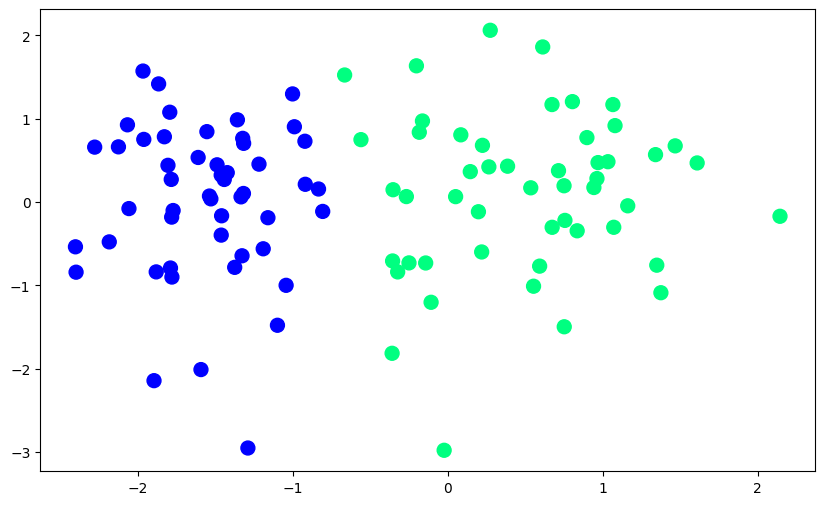

In [3]:
plt.figure(figsize = (10,6))
plt.scatter(X[:,0],X[:,1],c = y,cmap = 'winter',s = 100)

In [4]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [5]:
def step(z):
    return 1 if z>0 else 0

In [6]:
intercept_,coef_ = perceptron(X,y)

In [7]:
print(coef_)
print(intercept_)

[1.36497741 0.0294277 ]
1.0


In [8]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [9]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

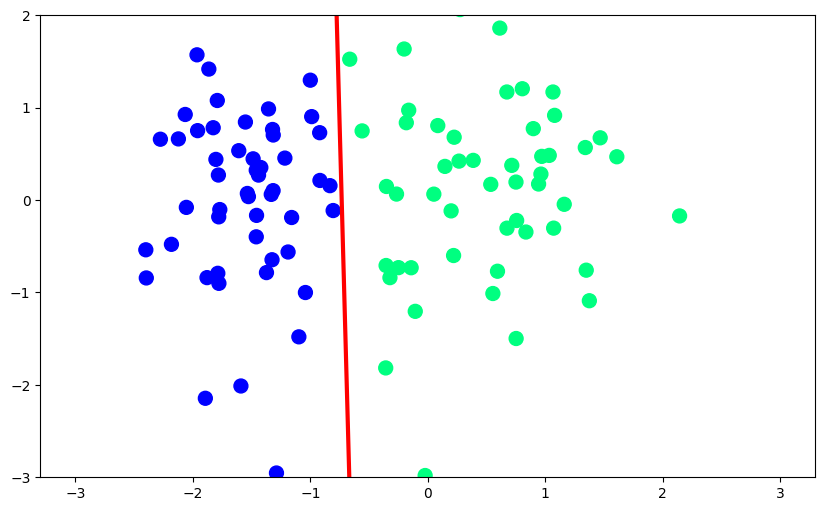

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)


In [11]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [12]:
m,b = perceptron(X,y)


In [15]:
%matplotlib widget
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

/opt/homebrew/anaconda3/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


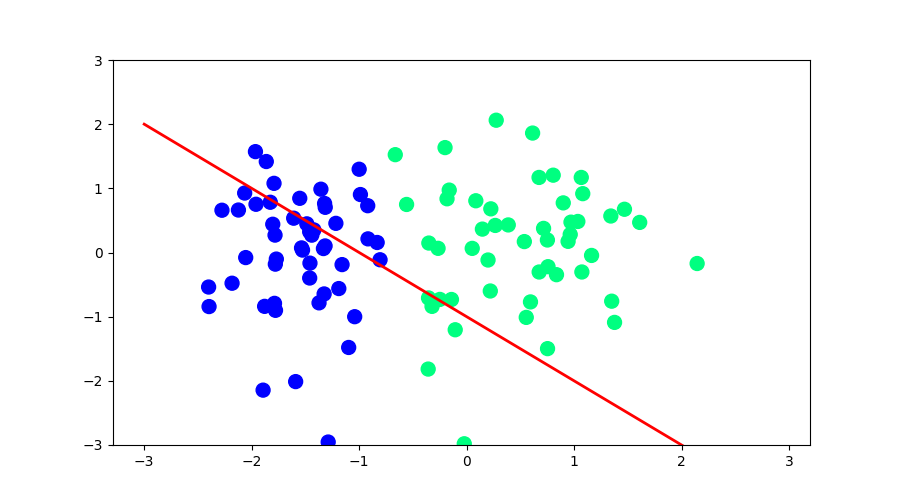

In [16]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

In [18]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

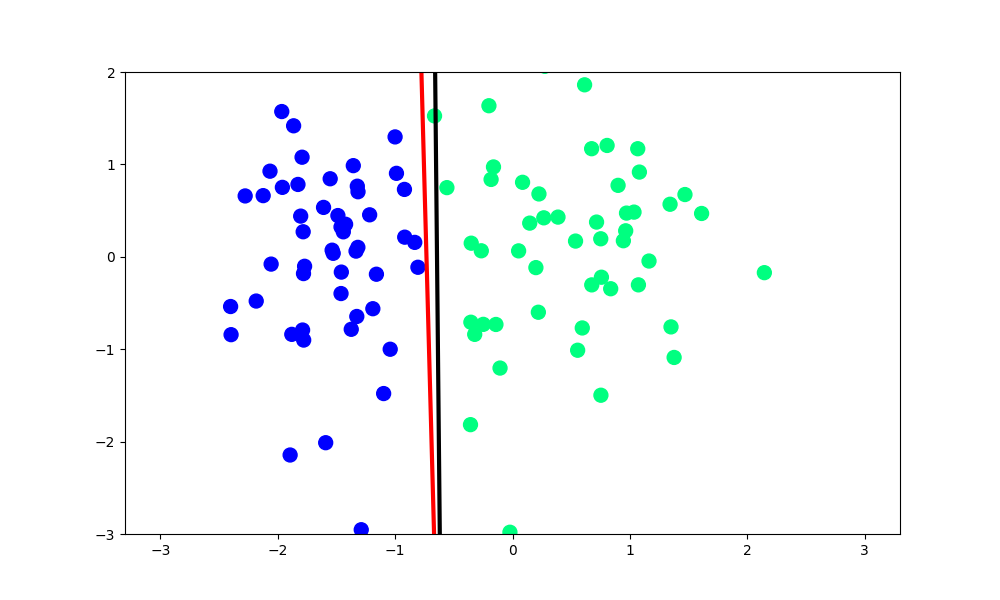

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)